# Aggregate climate data and export to Chap CSV

This notebook shows how to connect to a running instance of Open Climate Service (OCS), aggregate climate data to administrative boundaries, and export the results to a CSV file compatible with the [Chap Modeling Platform](https://chap.dhis2.org/).

## Prerequisites

- A running instance of OCS, including:
    1. Dataset id of an imported raster dataset of a climate variable.
    2. Dataset id of an imported vector dataset of administrative areas to aggregate to.

## Imports

In [30]:
import geopandas as gpd
import xarray as xr
import rioxarray
import pandas as pd
import openeo
import matplotlib.pyplot as plt

## Connect to OCS

If you don't already have an OCS instance, see the [installation guide](https://open-climate-service.dhis2.org/setup_guide/) to get one up and running.

OCS instances are tied to particular countries and bounding extents. In this notebook we showcase the results for a Rwanda OCS instance, but the notebook will work for whichever country or area your OCS instance is configured for. 

Provide your instance url below and confirm that you can connect to it:

In [31]:
ocs_url = "http://localhost:9000"
conn = openeo.connect(ocs_url)
conn

<Connection to 'http://localhost:9000' with NullAuth>


## Climate data

Make sure you have imported a climate dataset, containing the data which you would like to aggregate. For this notebook we showcase the aggregation of ERA5-Land temperature, but you can also specify another dataset id below. 

In [ ]:
# imported dataset id
climate_dataset_id = "era5land_temperature_daily"
climate_zarr_url = f"{ocs_url}/zarr/{climate_dataset_id}"

# open zarr archive as xarray
ds = xr.open_zarr(
    climate_zarr_url,
    consolidated=True,
)
ds

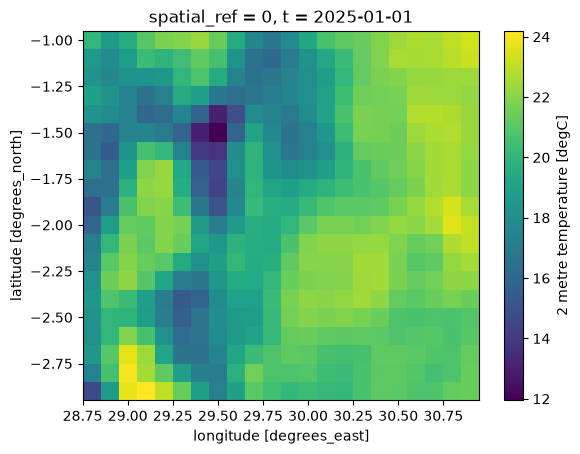

In [ ]:
# explore contents
ds["t2m"].isel(t=0).plot()

## Administrative Areas

Make sure you have imported the administrative areas that you want to use for aggregating and reporting climate statistics. These are the locations for which climate data is reported in your final Chap CSV file. 

You can use any polygon-based vector dataset, but an easy way to get started is using the builtin Overture Maps vector data source:

- Configure which boundaries you would like to import following [this guide](https://open-climate-service.dhis2.org/built_in_datasets/?h=overture#overture-maps-administrative-divisions-feature-collection).
- Trigger the import from the [Overture Maps data source page](http://localhost:9000/data-sources/overture_divisions). 

In [37]:
# the dataset id for imported boundaries
boundaries_dataset_id = "overture_divisions_adm3"
boundaries_features_url = f"{ocs_url}/features/{boundaries_dataset_id}/data.parquet"

# open the data as parquet
boundaries = gpd.read_parquet(boundaries_features_url)
boundaries

,geometry,id,subtype,class,name,country,region,admin_level
0,"POLYGON ((28.89336 -2.4907, 28.89333 -2.49079,...",b3752063-bf50-465a-a845-c39e983321fc,locality,land,Mururu,RW,RW-04,None
1,"POLYGON ((28.92888 -2.49373, 28.92917 -2.49405...",44e2947c-b472-4900-b370-684f693904e2,locality,land,Gihundwe,RW,RW-04,None
2,"POLYGON ((28.92918 -2.49449, 28.92911 -2.4944,...",5cc1dcf3-cbda-439d-a9d3-5f65b859d282,locality,land,Kamembe,RW,RW-04,None
3,"POLYGON ((28.95439 -2.55921, 28.95489 -2.55978...",7e0d6c09-ab60-4673-a748-b8ad9a3e9884,locality,land,Nyakarenzo,RW,RW-04,None
4,"POLYGON ((28.9013 -2.61689, 28.90086 -2.61828,...",592bc1fb-a96d-4598-943b-b5fee2004970,locality,land,Gashonga,RW,RW-04,None
...,...,...,...,...,...,...,...,...
427,"POLYGON ((30.37234 -1.7655, 30.37075 -1.7637, ...",c799ca1f-0230-43a5-83a3-0b2b9dc95bc6,locality,land,Murambi,RW,RW-02,None
428,"POLYGON ((30.30442 -1.59241, 30.30215 -1.58919...",38252c6d-6225-4860-8102-5b7e038c28d6,locality,land,Gitoki,RW,RW-02,None
429,"POLYGON ((30.23197 -1.25152, 30.23186 -1.25175...",fba48afe-2985-4cf0-86d8-5da800142a6c,locality,land,Rwempasha,RW,RW-02,None
430,"POLYGON ((30.78244 -2.14565, 30.78307 -2.14571...",8d5dd519-069e-42f0-8e75-2efd0d52e045,locality,land,Mpanga,RW,RW-02,None


<Axes: title={'center': 'spatial_ref = 0, t = 2025-01-01'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

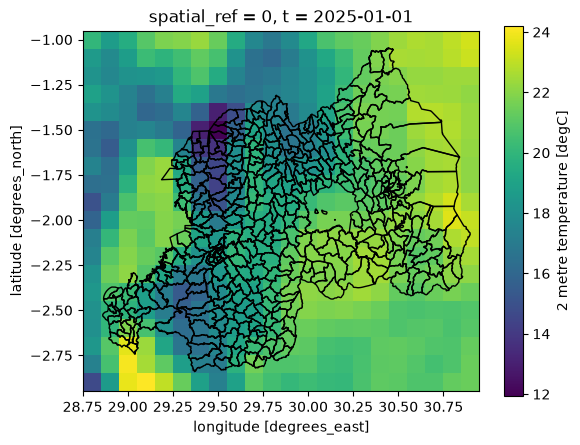

In [38]:
# visualize together with climate
ax = plt.subplot(1, 1, 1)

# plot climate
ds["t2m"].isel(t=0).plot(ax=ax)

# add boundaries
boundaries.plot(ax=ax, color="none")

## Aggregate to Chap CSV

All instances of OCS comes with a builtin workflow for spatially aggregating data to Chap-compatible CSV format - which we run below:

In [42]:
# trigger and wait for the workflow
csvdata = conn.download(
    {
        "process_graph": {
            "1": {
                "process_id": "aggregate_to_chap_csv",
                "arguments": {
                    "dataset_id": climate_dataset_id,
                    "temporal_extent": ["2025-01-01", "2025-01-31"],
                    "geometries": boundaries.__geo_interface__,
                    "method": "mean",
                    "period_type": "day",
                },
                "result": True,
            }
        }
    }
)

# save to disk
csv_path = "outputs/aggregate_chap.csv"
with open(csv_path, "wb") as w:
    w.write(csvdata)

# load the csv file to pandas
df = pd.read_csv(csv_path)

# inspect the data
print(df[df.time_period == 20250101])

       time_period                                           location  \
0         20250101  POLYGON ((28.8933616 -2.4906985, 28.8933253 -2...   
31        20250101  POLYGON ((28.9288822 -2.4937262, 28.9291743 -2...   
62        20250101  POLYGON ((28.9291796 -2.4944911, 28.9291065 -2...   
93        20250101  POLYGON ((28.9543948 -2.559209, 28.9548936 -2....   
124       20250101  POLYGON ((28.9013032 -2.6168938, 28.9008645 -2...   
...            ...                                                ...   
13237     20250101  POLYGON ((30.3723358 -1.7655047, 30.3707489 -1...   
13268     20250101  POLYGON ((30.3044246 -1.5924053, 30.3021546 -1...   
13299     20250101  POLYGON ((30.2319694 -1.2515164, 30.2318635 -1...   
13330     20250101  POLYGON ((30.7824413 -2.1456481, 30.7830745 -2...   
13361     20250101  POLYGON ((30.8486983 -2.1997778, 30.8490851 -2...   

          result  
0      19.941111  
31     20.311830  
62     19.943756  
93     20.035330  
124    20.469115  
...      